Note: you may need to restart the kernel to use updated packages.
Loaded BNN surrogate.
[RL] episode 1/1300, epsilon=0.250



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[RL] episode 250/1300, epsilon=0.195
[RL] episode 1000/1300, epsilon=0.092
[RL] episode 1300/1300, epsilon=0.068
Training complete (bi-adaptive + BNN).


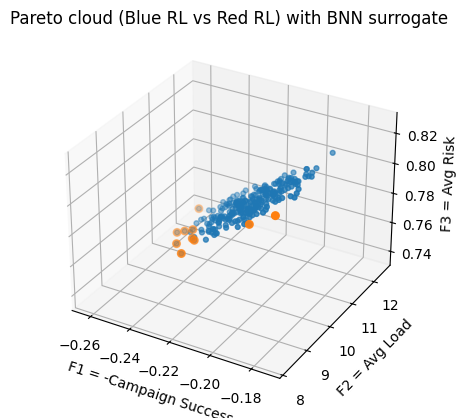

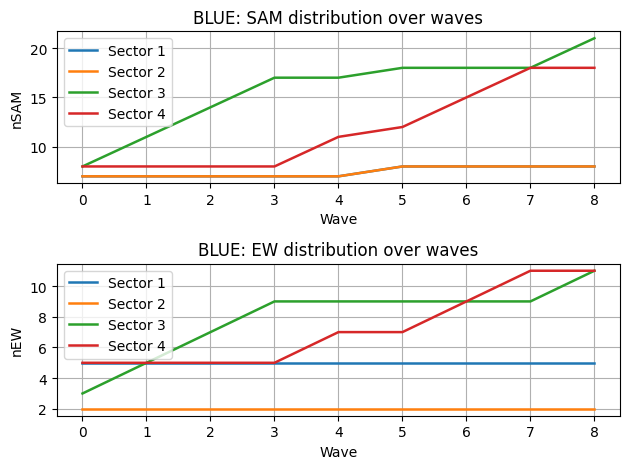

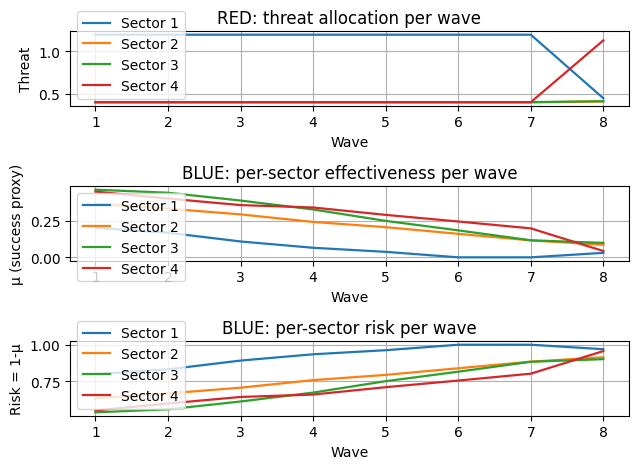

In [5]:
%pip install numpy torch matplotlib

import os
import pickle
import math
import random
from dataclasses import dataclass
from typing import Tuple, Dict, Any

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


# =========================
# Reproducibility
# =========================
def set_seed(seed: int = 1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# =========================
# Normalizer
# =========================
@dataclass
class ZNorm:
    mu: np.ndarray
    sig: np.ndarray

    def transform(self, x: np.ndarray) -> np.ndarray:
        return (x - self.mu) / self.sig

    def inverse(self, z: np.ndarray) -> np.ndarray:
        return z * self.sig + self.mu


# =========================
# "True" Monte-Carlo wave model (labels)
# =========================
def simulate_wave_mc(
    nSAM: np.ndarray,
    nEW: np.ndarray,
    Ammo: np.ndarray,
    Ammo0: np.ndarray,
    fatigue: float,
    threat: np.ndarray,
    mc: int = 60,
) -> np.ndarray:
    """
    Aggregated 'true' wave model returning mu per sector in [0,1], averaged over MC.
    Shapes: nSAM,nEW,Ammo,Ammo0,threat are (S,), fatigue scalar.
    """
    S = nSAM.shape[0]
    ammo_factor = np.minimum(1.0, Ammo / np.maximum(1e-6, Ammo0))

    mu_runs = np.zeros((mc, S), dtype=np.float64)

    for r in range(mc):
        noise = 0.03 * np.random.randn(S)
        threat_noise = threat * (1.0 + 0.10 * np.random.randn(S))
        threat_noise = np.maximum(0.0, threat_noise)

        mu_r = (
            0.50 * (1.0 - np.exp(-0.25 * nSAM))
            + 0.30 * (1.0 - np.exp(-0.30 * nEW))
            - 0.35 * threat_noise
        )

        mu_r = mu_r * ammo_factor * (1.0 - 0.35 * fatigue) + noise
        mu_r = np.clip(mu_r, 0.0, 1.0)

        mu_runs[r, :] = mu_r

    return mu_runs.mean(axis=0)


# =========================
# BNN Surrogate (MC Dropout)
# =========================
class DropoutBNN(nn.Module):
    def __init__(self, in_dim: int = 17, out_dim: int = 4, p: float = 0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(64, out_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_mc_dataset(n_samples: int, n_sectors: int, threat_budget: float = 2.4) -> Tuple[np.ndarray, np.ndarray, Dict[str, ZNorm]]:
    """
    Features per sample:
      [nSAM(4), nEW(4), ammoFactor(4), fatigue(1), threat(4)] => 17 dims
    Labels:
      mu(4) from simulate_wave_mc
    Returns normalized (z-scored) X,Y and norms.
    """
    X = np.zeros((n_samples, 17), dtype=np.float64)
    Y = np.zeros((n_samples, n_sectors), dtype=np.float64)

    for i in range(n_samples):
        nSAM = np.random.randint(2, 13, size=(n_sectors,))        # 2..12
        nEW  = np.random.randint(1, 9, size=(n_sectors,))         # 1..8

        Ammo0 = 15.0 + 20.0 * np.random.rand(n_sectors)
        Ammo  = Ammo0 * np.random.rand(n_sectors)                 # random depletion

        fatigue = float(np.random.rand())

        base_threat = 0.30 + 0.50 * np.random.rand(n_sectors)
        w = 0.5 + np.random.rand(n_sectors)                       # random allocation weights
        threat = threat_budget * (w / w.sum()) * base_threat
        threat = np.maximum(0.01, threat)

        mu = simulate_wave_mc(nSAM, nEW, Ammo, Ammo0, fatigue, threat, mc=60)
        ammo_factor = np.minimum(1.0, Ammo / np.maximum(1e-6, Ammo0))

        feats = np.concatenate([nSAM, nEW, ammo_factor, np.array([fatigue]), threat], axis=0)
        X[i, :] = feats
        Y[i, :] = mu

    # z-score
    muX = X.mean(axis=0)
    sigX = X.std(axis=0) + 1e-8
    muY = Y.mean(axis=0)
    sigY = Y.std(axis=0) + 1e-8

    normX = ZNorm(muX, sigX)
    normY = ZNorm(muY, sigY)

    Xn = normX.transform(X).astype(np.float32)
    Yn = normY.transform(Y).astype(np.float32)

    norms = {"X": normX, "Y": normY}
    return Xn, Yn, norms


def train_bnn(Xn: np.ndarray, Yn: np.ndarray, epochs: int = 20, batch_size: int = 512, lr: float = 1e-3, device: str = "cpu") -> DropoutBNN:
    model = DropoutBNN(in_dim=Xn.shape[1], out_dim=Yn.shape[1], p=0.15).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_t = torch.from_numpy(Xn).to(device)
    Y_t = torch.from_numpy(Yn).to(device)

    n = Xn.shape[0]
    idx = np.arange(n)

    model.train()
    for ep in range(1, epochs + 1):
        np.random.shuffle(idx)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            xb = X_t[batch]
            yb = Y_t[batch]

            opt.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()

        if ep in {1, 5, 10, epochs}:
            print(f"[BNN] epoch {ep:02d}/{epochs}, loss={loss.item():.5f}")

    return model


@torch.no_grad()
def bnn_predict_mu_sigma(
    model: DropoutBNN,
    norms: Dict[str, ZNorm],
    nSAM: np.ndarray,
    nEW: np.ndarray,
    Ammo: np.ndarray,
    Ammo0: np.ndarray,
    fatigue: float,
    threat: np.ndarray,
    mc_passes: int = 40,
    device: str = "cpu",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    MC Dropout prediction. Returns mu_pred (S,), sigma_pred (S,) in real scale.
    """
    ammo_factor = np.minimum(1.0, Ammo / np.maximum(1e-6, Ammo0))
    x = np.concatenate([nSAM, nEW, ammo_factor, np.array([fatigue]), threat], axis=0).astype(np.float64)

    Xn = norms["X"].transform(x[None, :]).astype(np.float32)
    xt = torch.from_numpy(Xn).to(device)

    # enable dropout at inference: keep model in train() but without gradients
    model.train()

    preds = []
    for _ in range(mc_passes):
        y = model(xt)  # normalized
        preds.append(y.cpu().numpy())

    preds = np.concatenate(preds, axis=0)  # (K, S)
    y_mean = preds.mean(axis=0)
    y_std = preds.std(axis=0)

    mu_real = norms["Y"].inverse(y_mean)
    sig_real = y_std * norms["Y"].sig

    mu_real = np.clip(mu_real, 0.0, 1.0)
    sig_real = np.maximum(0.0, sig_real)
    return mu_real, sig_real


# =========================
# RL helpers: states/actions
# =========================
def discretize_levels(x: np.ndarray, n_levels: int) -> np.ndarray:
    # bins: [0..1] -> 1..n_levels
    edges = np.linspace(0.0, 1.0, n_levels + 1)
    lvl = np.digitize(x, edges, right=False)  # 1..n_levels+1
    lvl = np.clip(lvl, 1, n_levels)
    return lvl.astype(int)


def baseN_index(levels_1based: np.ndarray, base: int) -> int:
    # levels are 1..base, convert to 0-based then compute mixed-radix index
    lv = levels_1based - 1
    idx = 0
    mult = 1
    for v in lv:
        idx += int(v) * mult
        mult *= base
    return idx  # 0-based


def encode_state_risk(risk: np.ndarray, n_levels: int, last_red_action: int, n_red_actions: int) -> int:
    # state = last_red_action block + risk pattern
    levels = discretize_levels(risk, n_levels)
    core = baseN_index(levels, n_levels)
    block = (last_red_action - 1) * (n_levels ** risk.size)
    return block + core  # 0-based


def encode_state_density(density: np.ndarray, n_levels: int, last_blue_action: int, n_blue_actions: int) -> int:
    levels = discretize_levels(density, n_levels)
    core = baseN_index(levels, n_levels)
    block = (last_blue_action - 1) * (n_levels ** density.size)
    return block + core  # 0-based


def epsilon_greedy(Q: np.ndarray, state: int, eps: float) -> int:
    if random.random() < eps:
        return random.randrange(Q.shape[1])  # 0..A-1
    return int(np.argmax(Q[state, :]))


def red_action_to_threat(action: int, base_threat: np.ndarray, budget: float) -> np.ndarray:
    # actions: 0..4 => focus sector 0..3, or spread
    w = np.ones_like(base_threat, dtype=np.float64)
    if action == 0: w = np.array([2.2, 0.8, 0.8, 0.8])
    if action == 1: w = np.array([0.8, 2.2, 0.8, 0.8])
    if action == 2: w = np.array([0.8, 0.8, 2.2, 0.8])
    if action == 3: w = np.array([0.8, 0.8, 0.8, 2.2])
    if action == 4: w = np.array([1.0, 1.0, 1.0, 1.0])

    raw = np.maximum(0.01, base_threat * w)
    return budget * (raw / raw.sum())


def blue_apply_action(nSAM: np.ndarray, nEW: np.ndarray, action: int, res_sam: int, res_ew: int) -> Tuple[np.ndarray, np.ndarray]:
    # actions: 0..4 => focus sector 0..3 or spread
    nSAM2 = nSAM.copy()
    nEW2 = nEW.copy()

    if action in (0, 1, 2, 3):
        s = action
        nSAM2[s] += res_sam
        nEW2[s] += res_ew
    else:
        nSAM2 += int(round(res_sam / len(nSAM2)))
        nEW2  += int(round(res_ew  / len(nEW2)))

    return nSAM2, nEW2


# =========================
# Pareto mask
# =========================
def pareto_mask(F: np.ndarray) -> np.ndarray:
    n = F.shape[0]
    mask = np.ones(n, dtype=bool)
    for i in range(n):
        if not mask[i]:
            continue
        for j in range(n):
            if i == j:
                continue
            if np.all(F[j, :] <= F[i, :]) and np.any(F[j, :] < F[i, :]):
                mask[i] = False
                break
    return mask


# =========================
# One greedy episode for plotting
# =========================
@dataclass
class Traj:
    nSAM: np.ndarray       # (T+1,S)
    nEW: np.ndarray        # (T+1,S)
    threat: np.ndarray     # (T,S)
    mu: np.ndarray         # (T,S)
    risk: np.ndarray       # (T,S)


def run_episode_greedy(
    QB: np.ndarray,
    QR: np.ndarray,
    T: int,
    n_sectors: int,
    n_risk_levels: int,
    n_den_levels: int,
    res_sam: int,
    res_ew: int,
    threat_budget: float,
    use_bnn: bool,
    bnn: DropoutBNN,
    norms: Dict[str, ZNorm],
    device: str = "cpu",
) -> Tuple[np.ndarray, Traj]:
    nSAM = np.random.randint(4, 11, size=(n_sectors,))
    nEW  = np.random.randint(2,  7, size=(n_sectors,))
    Ammo0 = 20.0 + 10.0 * np.random.rand(n_sectors)
    Ammo  = Ammo0.copy()
    fatigue = 0.0
    base_threat = 0.45 + 0.20 * np.random.rand(n_sectors)

    last_red_action = 4  # "spread" in 0..4 indexing
    last_blue_action = 4

    traj = Traj(
        nSAM=np.zeros((T + 1, n_sectors)),
        nEW=np.zeros((T + 1, n_sectors)),
        threat=np.zeros((T, n_sectors)),
        mu=np.zeros((T, n_sectors)),
        risk=np.zeros((T, n_sectors)),
    )
    traj.nSAM[0, :] = nSAM
    traj.nEW[0, :] = nEW

    mu_acc = 0.0
    risk_acc = 0.0
    load_acc = 0.0

    for t in range(T):
        density = (nSAM + nEW) / max(1.0, float((nSAM + nEW).sum()))
        sR = encode_state_density(density, n_den_levels, last_blue_action + 1, 5)
        aR = int(np.argmax(QR[sR, :]))
        threat = red_action_to_threat(aR, base_threat, threat_budget)
        last_red_action = aR

        if use_bnn:
            mu_sector, _ = bnn_predict_mu_sigma(bnn, norms, nSAM, nEW, Ammo, Ammo0, fatigue, threat, mc_passes=40, device=device)
        else:
            mu_sector = simulate_wave_mc(nSAM, nEW, Ammo, Ammo0, fatigue, threat, mc=30)
        risk = 1.0 - mu_sector

        sB = encode_state_risk(risk, n_risk_levels, last_red_action + 1, 5)
        aB = int(np.argmax(QB[sB, :]))
        nSAM2, nEW2 = blue_apply_action(nSAM, nEW, aB, res_sam, res_ew)
        last_blue_action = aB

        shots = 1.5 + 3.0 * threat
        Ammo = np.maximum(0.0, Ammo - shots)
        load = float(np.mean(0.7 * nSAM2 + 0.5 * nEW2))
        fatigue = min(1.0, fatigue + 0.05 * (load / (load + 10.0)))

        # evaluate after move for KPI accumulation
        if use_bnn:
            mu_next, _ = bnn_predict_mu_sigma(bnn, norms, nSAM2, nEW2, Ammo, Ammo0, fatigue, threat, mc_passes=40, device=device)
        else:
            mu_next = simulate_wave_mc(nSAM2, nEW2, Ammo, Ammo0, fatigue, threat, mc=30)
        risk_next = 1.0 - mu_next

        mu_acc += float(mu_next.mean())
        risk_acc += float(risk_next.mean())
        load_acc += float(np.mean(0.7 * nSAM2 + 0.5 * nEW2))

        traj.threat[t, :] = threat
        traj.mu[t, :] = mu_next
        traj.risk[t, :] = risk_next
        traj.nSAM[t + 1, :] = nSAM2
        traj.nEW[t + 1, :] = nEW2

        nSAM, nEW = nSAM2, nEW2

    muC = mu_acc / T
    riskC = risk_acc / T
    loadC = load_acc / T
    Frow = np.array([-muC, loadC, riskC], dtype=np.float64)
    return Frow, traj


# =========================
# MAIN
# =========================
def main():
    set_seed(1)

    # ----- Core configuration (close to MATLAB "first version") -----
    n_sectors = 4
    T = 8
    episodes = 1300
    eval_runs = 250

    # BLUE reward weights
    alphaB, betaB, gammaB = 1.0, 0.25, 0.75
    # RED reward weights
    alphaR, betaR, gammaR = 1.0, 0.10, 0.15

    # RL hyperparams
    eps0, eps_min, eps_decay = 0.25, 0.05, 0.999
    lr_q, disc = 0.10, 0.90

    # Reserves & threat budget
    res_sam, res_ew = 3, 2
    threat_budget = 2.4

    # Discretization
    n_risk_levels = 3
    n_den_levels = 3

    # Action space: 5 actions
    n_actions = 5

    # State sizes (same logic as MATLAB)
    n_states_B = (n_risk_levels ** n_sectors) * n_actions
    n_states_R = (n_den_levels ** n_sectors) * n_actions

    QB = np.zeros((n_states_B, n_actions), dtype=np.float64)
    QR = np.zeros((n_states_R, n_actions), dtype=np.float64)

    # ----- BNN surrogate -----
    use_bnn = True
    device = "cuda" if torch.cuda.is_available() else "cpu"
    bnn_path = "bnn_surrogate.pt"
    norm_path = "bnn_norms.pkl"

    if use_bnn and (os.path.isfile(bnn_path) and os.path.isfile(norm_path)):
        with open(norm_path, "rb") as f:
            norms = pickle.load(f)
        bnn = DropoutBNN(in_dim=17, out_dim=4, p=0.15).to(device)
        bnn.load_state_dict(torch.load(bnn_path, map_location=device))
        print("Loaded BNN surrogate.")
    elif use_bnn:
        print("Training BNN surrogate on Monte-Carlo dataset...")
        Xn, Yn, norms = build_mc_dataset(n_samples=25000, n_sectors=n_sectors, threat_budget=threat_budget)
        bnn = train_bnn(Xn, Yn, epochs=20, batch_size=512, lr=1e-3, device=device)
        torch.save(bnn.state_dict(), bnn_path)
        with open(norm_path, "wb") as f:
            pickle.dump(norms, f)
        print("BNN surrogate saved.")
    else:
        bnn, norms = None, None

    # ----- Bi-adaptive RL training -----
    eps = eps0
    for ep in range(1, episodes + 1):
        nSAM = np.random.randint(4, 11, size=(n_sectors,))
        nEW  = np.random.randint(2,  7, size=(n_sectors,))
        Ammo0 = 20.0 + 10.0 * np.random.rand(n_sectors)
        Ammo  = Ammo0.copy()
        fatigue = 0.0
        base_threat = 0.45 + 0.20 * np.random.rand(n_sectors)

        last_red_action = 4
        last_blue_action = 4

        for t in range(T):
            # RED chooses threat allocation
            density = (nSAM + nEW) / max(1.0, float((nSAM + nEW).sum()))
            sR = encode_state_density(density, n_den_levels, last_blue_action + 1, n_actions)
            aR = epsilon_greedy(QR, sR, eps)
            threat = red_action_to_threat(aR, base_threat, threat_budget)
            last_red_action = aR

            # BLUE observes and moves
            if use_bnn:
                mu_sector, _ = bnn_predict_mu_sigma(bnn, norms, nSAM, nEW, Ammo, Ammo0, fatigue, threat, mc_passes=40, device=device)
            else:
                mu_sector = simulate_wave_mc(nSAM, nEW, Ammo, Ammo0, fatigue, threat, mc=30)

            risk = 1.0 - mu_sector
            sB = encode_state_risk(risk, n_risk_levels, last_red_action + 1, n_actions)

            aB = epsilon_greedy(QB, sB, eps)
            nSAM2, nEW2 = blue_apply_action(nSAM, nEW, aB, res_sam, res_ew)
            last_blue_action = aB

            # update ammo/fatigue
            shots = 1.5 + 3.0 * threat
            Ammo = np.maximum(0.0, Ammo - shots)
            loadB = float(np.mean(0.7 * nSAM2 + 0.5 * nEW2))
            fatigue = min(1.0, fatigue + 0.05 * (loadB / (loadB + 10.0)))

            # next evaluation
            if use_bnn:
                mu_next, sig_next = bnn_predict_mu_sigma(bnn, norms, nSAM2, nEW2, Ammo, Ammo0, fatigue, threat, mc_passes=40, device=device)
            else:
                mu_next = simulate_wave_mc(nSAM2, nEW2, Ammo, Ammo0, fatigue, threat, mc=30)
                sig_next = np.zeros_like(mu_next)

            risk_next = 1.0 - mu_next

            muB = float(mu_next.mean())
            riskB = float(risk_next.mean())
            uncB = float(sig_next.mean())

            # BLUE reward (risk- & uncertainty-aware)
            rB = alphaB * muB - betaB * loadB - gammaB * riskB - 0.15 * uncB

            # RED reward: increase pressure / reduce blue success
            conc = float(np.std(threat) / (np.mean(threat) + 1e-6))
            rR = alphaR * (1.0 - muB) - betaR * conc - gammaR * float(np.mean(density))

            # next states
            density2 = (nSAM2 + nEW2) / max(1.0, float((nSAM2 + nEW2).sum()))
            sR2 = encode_state_density(density2, n_den_levels, last_blue_action + 1, n_actions)
            sB2 = encode_state_risk(risk_next, n_risk_levels, last_red_action + 1, n_actions)

            # Q updates
            QB[sB, aB] = QB[sB, aB] + lr_q * (rB + disc * np.max(QB[sB2, :]) - QB[sB, aB])
            QR[sR, aR] = QR[sR, aR] + lr_q * (rR + disc * np.max(QR[sR2, :]) - QR[sR, aR])

            nSAM, nEW = nSAM2, nEW2

        eps = max(eps_min, eps * eps_decay)

        if ep in {1, 250, 1000, episodes}:
            print(f"[RL] episode {ep}/{episodes}, epsilon={eps:.3f}")

    print("Training complete (bi-adaptive + BNN).")

    # ----- Evaluation (Pareto cloud) -----
    F = np.zeros((eval_runs, 3), dtype=np.float64)
    for k in range(eval_runs):
        Frow, _ = run_episode_greedy(
            QB, QR, T, n_sectors, n_risk_levels, n_den_levels,
            res_sam, res_ew, threat_budget,
            use_bnn, bnn, norms, device=device
        )
        F[k, :] = Frow

    mask = pareto_mask(F)
    Fp = F[mask, :]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(F[:, 0], F[:, 1], F[:, 2], s=12)
    ax.scatter(Fp[:, 0], Fp[:, 1], Fp[:, 2], s=30)
    ax.set_xlabel("F1 = -Campaign Success")
    ax.set_ylabel("F2 = Avg Load")
    ax.set_zlabel("F3 = Avg Risk")
    ax.set_title("Pareto cloud (Blue RL vs Red RL) with BNN surrogate")
    plt.show()

    # ----- One demo episode: force distribution over time -----
    _, traj = run_episode_greedy(
        QB, QR, T, n_sectors, n_risk_levels, n_den_levels,
        res_sam, res_ew, threat_budget,
        use_bnn, bnn, norms, device=device
    )

    plot_time_series(traj)


def plot_time_series(traj: Traj):
    T = traj.threat.shape[0]
    t_force = np.arange(0, T + 1)
    t_wave = np.arange(1, T + 1)

    # BLUE forces
    plt.figure()
    plt.subplot(2, 1, 1)
    for s in range(traj.nSAM.shape[1]):
        plt.plot(t_force, traj.nSAM[:, s], linewidth=1.8, label=f"Sector {s+1}")
    plt.grid(True)
    plt.xlabel("Wave")
    plt.ylabel("nSAM")
    plt.title("BLUE: SAM distribution over waves")
    plt.legend(loc="best")

    plt.subplot(2, 1, 2)
    for s in range(traj.nEW.shape[1]):
        plt.plot(t_force, traj.nEW[:, s], linewidth=1.8, label=f"Sector {s+1}")
    plt.grid(True)
    plt.xlabel("Wave")
    plt.ylabel("nEW")
    plt.title("BLUE: EW distribution over waves")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # RED threat & BLUE effectiveness
    plt.figure()
    plt.subplot(3, 1, 1)
    for s in range(traj.threat.shape[1]):
        plt.plot(t_wave, traj.threat[:, s], linewidth=1.6, label=f"Sector {s+1}")
    plt.grid(True)
    plt.xlabel("Wave")
    plt.ylabel("Threat")
    plt.title("RED: threat allocation per wave")
    plt.legend(loc="best")

    plt.subplot(3, 1, 2)
    for s in range(traj.mu.shape[1]):
        plt.plot(t_wave, traj.mu[:, s], linewidth=1.6, label=f"Sector {s+1}")
    plt.grid(True)
    plt.xlabel("Wave")
    plt.ylabel("μ (success proxy)")
    plt.title("BLUE: per-sector effectiveness per wave")
    plt.legend(loc="best")

    plt.subplot(3, 1, 3)
    for s in range(traj.risk.shape[1]):
        plt.plot(t_wave, traj.risk[:, s], linewidth=1.6, label=f"Sector {s+1}")
    plt.grid(True)
    plt.xlabel("Wave")
    plt.ylabel("Risk = 1-μ")
    plt.title("BLUE: per-sector risk per wave")
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()
